# Aspirin Hydrolysis Curve Fits

the data is from 
"The hydrolysis of aspirin." L.J. Edwards, *Trans. Faraday Soc.*, **1950**, *46*, 723-735. https://doi.org/10.1039/TF9504600723

## Load Data

The data table from the above paper was made into a csv file (`Edwards1950.csv`). The file contains pH and k_obs values. It is read into a dataframe with the pH va;ues as the index series.  Then a $\log{(K_{obs})}$ series is created and a series for $[H^+]$

In [92]:
#!pip install uncertainties
#!pip install lmfit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un               # tool set for handling uncertainties
from uncertainties import unumpy as unp  # a replacement for numpy 

import lmfit     

!mkdir plots

################################################################################
### Set global variables. Set flag accordingly
################################################################################

#github = True  
github = False  

if github:
    data_path = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_10/data/"
    image_path = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_10/images/"
    github_data_location = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"
    github_styles_location = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
else:
    data_path = "data/"
    image_path = "images/"
    github_data_location = "/Users/blink/github/LFER-QSAR/data/"
    github_styles_location = "../../styles/"

    

################################################################################
### Read data set. The fields are separated by commas; comments are enabled  
################################################################################

df = pd.read_csv(data_path + "Edwards1950.csv", 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="pH", 
                 comment = "#") 

################################################################################
### Process data  
################################################################################

df["logk"] = np.log10(df["k_obs"])        # get log(K) from K
df["H"]=10**(-df.index)                   # get [H] from pH
df.sort_values(by=['pH'], inplace=True)   # one value was out of order, sort to fix.

display(df.head())

mkdir: plots: File exists


,k_obs,logk,H
pH,,,
0.53,0.5780,-0.238072,0.295121
1.00,0.1900,-0.721246,0.100000
1.33,0.0835,-1.078314,0.046774
1.80,0.0450,-1.346787,0.015849
2.48,0.0267,-1.573489,0.003311


## Plot the Data

Below is code that will plot the log-log plot for the pH-rate profile. We will plot $\log{k_{obs}}$ vs. $pH$

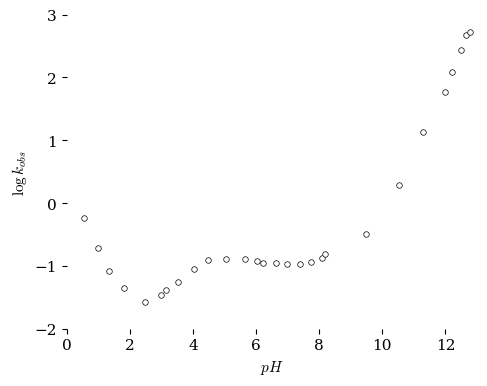

In [93]:
################################################################################
### Choose x and y for plot
################################################################################

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

################################################################################
### Setup a figure with two plots side-by-side and choose a stylesheet
################################################################################

# reset the default style settings for matplotlib so we always start from the same stylesheet
plt.rcParams.update(plt.rcParamsDefault)

# Choose a style sheet for the plot. The stylesheets are in the "styles" folder of the GitHub repository.
plt.style.use(github_styles_location + "tufte.mplstyle")        
#plt.style.use(github_styles_location + "S2_classic2.mplstyle")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

################################################################################
### Plot the data    
################################################################################

ax.scatter(x, y, 
           marker = "o", s=16, 
           color="white", edgecolor = "black",
           linewidth = 0.5, zorder=3)
   
################################################################################
### Set labels and scale 
################################################################################

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
       xlim=[0,13],                  
       ylim=[-2,3],     
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

################################################################################
### Output the final plot 
################################################################################

fig.savefig("plots/01_plot_pH.pdf")   # use this to save the figure in PDF format
plt.show()                            # output the plot to the screen

## Using LMFit

The below code will perform the same curve fit as above using the LMFit package rather than scipy.optimize.curve_fit. the detailed report from LMFit is advantageous and its built-in tools for calculating the fit line and the confidence band are also helpful.

First we define the components of the pH-rate profile

## Defining Functions

The functions below describe each mechanism in the model. And then a final model is created that calculates the sum of the rate constant contributions from each component to give the total observed rate constant, $k_{obs}$. 

In [ ]:
################################################################################
### Functions that define each component's rate constant
################################################################################

def genbase(pH, pKa=3.55, k= 0.119): # fit the intramolecular general base-catalyzed rate
    Ka = 10**(-pKa)
    H = 10**(-pH)
    frac_base = Ka/(H + Ka)
    rateconst = k * frac_base
    return rateconst

def genacid(pH, pKa=3.55, k=0.01):   # fit the water rate (kinetically indistiguishable from GA)
    Ka = 10**(-pKa)
    H = 10**(-pH)
    frac_acid = H/(Ka + H) # The fraction in the protonated, neutral form is H/(Ka + H)
    rateconst = k * frac_acid
    return rateconst

def specificacid(pH, k= 1.88):   # fit the specific acid-catalyzed rate 
    H = 10**(-pH)
    rateconst = (H*k)
    return rateconst    
    
def specificbase(pH, k=7970, pKa=3.55, pKW=14):  # fit the specific base-catalyzed rate
    H = 10**(-pH)
    KW = 10**(-pKW)
    OH = KW / H
    Ka = 10**(-pKa)
    frac_base = Ka/(H + Ka)
    rateconst = (OH*k*frac_base)
    return rateconst   

################################################################################
### Function that defines the model - used in curve fit
################################################################################

def aspirin_model(pH, ka = 1.88, kb=0.01, kc = 0.119, kd = 7970, pKa = 3.55, pKW = 14):    
    """
    aspirin_model(pH, ka, kb, kc, kd, pKa, pKW) - model for the pH-rate profile of aspirin hydrolysis
    pH is an array of pH values
    returns an array of k_obs values
    """
    H = 10**(-pH)
    k_obs = specificacid(pH, ka) + genacid(pH, pKa, kb) + genbase(pH, pKa, kc) + specificbase(pH, kd, pKa, pKW)
    return np.log10(k_obs)



### Test the Code

Below I plot the data against values that are known. The plot generated from the functions matches the data. 

Always test early and often. If you make any improvements to the code, test again. Test, test, test.

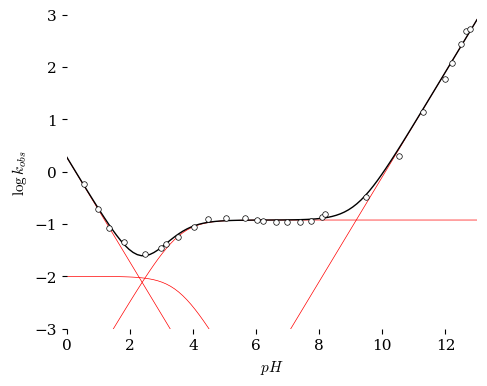

In [103]:
################################################################################
### Choose x and y for plot
################################################################################

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

x_fit = np.linspace(0, 13, 100)  # create a smooth x array for plotting the model
y_fit = aspirin_model(x_fit)

################################################################################
### Setup a figure with two plots side-by-side and choose a stylesheet
################################################################################

# reset the default style settings for matplotlib so we always start from the same stylesheet
plt.rcParams.update(plt.rcParamsDefault)

# Choose a style sheet for the plot. The stylesheets are in the "styles" folder of the GitHub repository.
plt.style.use(github_styles_location + "tufte.mplstyle")        
#plt.style.use(github_styles_location + "S2_classic2.mplstyle")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

################################################################################
### Plot the data    
################################################################################

ax.scatter(x, y, 
           marker = "o", s=16, 
           color="white", edgecolor = "black",
           linewidth = 0.5, zorder=3)

################################################################################
### Plot the results of known values in black    
################################################################################

ax.plot(x_fit, y_fit, 
        color="black", linewidth=1, zorder=2)

################################################################################
### Plot the results of known values for components in red    
################################################################################

y_fit = np.log10(specificacid(x_fit, k=1.88))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(genacid(x_fit, pKa=3.55, k=0.01))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(genbase(x_fit, pKa=3.55, k=0.119))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(specificbase(x_fit, k=7970, pKa=3.55, pKW=14))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)
 
################################################################################
### Set labels and scale 
################################################################################

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
       xlim=[0,13],                  
       ylim=[-3,3],     
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

################################################################################
### Output the final plot 
################################################################################

fig.savefig("plots/01_plot_pH.pdf")   # use this to save the figure in PDF format
plt.show()                            # output the plot to the screen

### Perform a Curve Fit

Using the model, let us fit it against the data using LMFit

In [132]:
from lmfit import Model

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

gmodel = Model(aspirin_model, nan_policy='omit')
params = gmodel.make_params(                    # initial values and constraints
                        ka = dict(value = 1.5, min = 1E-15, max = 100),
                        kb = dict(value = 0.015, min = 1E-15, max = 100),
                        kc = dict(value = 0.15, min = 1E-15, max = 100),
                        kd = dict(value = 10000, min = 1, max = 100000),
                        pKa = dict(value = 4., min = 1, max = 10),
                        pKW = dict(value = 14.3, vary = False)
                        )    
# note: in fitting a model, all parameters must be named in the model function, 
# even if they are not varied. The parameters that are not varied can be set 
# to a fixed value in the make_params() call. The x variable must also be named 
# in the model function.
result = gmodel.fit(y, params, pH=x)

print(result.fit_report())

[[Model]]
    Model(aspirin_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 37
    # data points      = 28
    # variables        = 5
    chi-square         = 0.09112114
    reduced chi-square = 0.00396179
    Akaike info crit   = -150.377559
    Bayesian info crit = -143.716536
    R-squared          = 0.99816138
[[Variables]]
    ka:   1.74957492 +/- 0.17394188 (9.94%) (init = 1.5)
    kb:   0.01384847 +/- 0.00459635 (33.19%) (init = 0.015)
    kc:   0.11987210 +/- 0.00543026 (4.53%) (init = 0.15)
    kd:   15075.7599 +/- 808.222341 (5.36%) (init = 10000)
    pKa:  3.65409038 +/- 0.12326587 (3.37%) (init = 4)
    pKW:  14.3 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(kb, pKa) = +0.7450
    C(ka, kb)  = -0.5346
    C(kc, pKa) = +0.3992
    C(ka, pKa) = -0.3540
    C(kb, kc)  = +0.1261


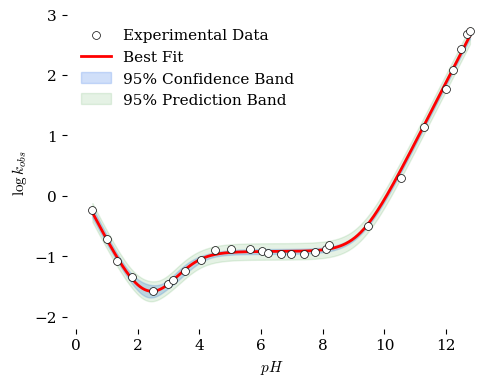

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

###############################################################################
# Generate smooth curve
###############################################################################

pH_fit = np.linspace(
    np.min(x),
    np.max(x),
    500
)

# Best-fit curve
y_fit = result.eval(pH=pH_fit)

###############################################################################
# Retrieve covariance matrix
###############################################################################

cov = result.covar

if cov is None:
    raise RuntimeError(
        "LMFit did not return a covariance matrix.\n"
        "Confidence intervals cannot be calculated."
    )

###############################################################################
# Numerical Jacobian
###############################################################################

param_names = result.var_names
npar = len(param_names)

# Jacobian matrix:
# rows = pH values
# columns = model parameters

jacobian = np.zeros((len(pH_fit), npar))

eps = 1e-7

for j, pname in enumerate(param_names):

    value = result.params[pname].value

    # Relative perturbation
    step = eps * max(abs(value), 1.0)

    pars_plus = result.params.copy()
    pars_minus = result.params.copy()

    pars_plus[pname].value = value + step
    pars_minus[pname].value = value - step

    y_plus = gmodel.eval(
        pars_plus,
        pH=pH_fit
    )

    y_minus = gmodel.eval(
        pars_minus,
        pH=pH_fit
    )

    # Central finite difference derivative
    jacobian[:, j] = (
        y_plus - y_minus
    ) / (2.0 * step)

###############################################################################
# Propagate covariance matrix
###############################################################################

var_mean = np.zeros(len(pH_fit))

for i in range(len(pH_fit)):

    J = jacobian[i, :]

    # J C J^T
    var_mean[i] = J @ cov @ J.T

# Numerical noise can occasionally produce tiny negative values
var_mean = np.maximum(var_mean, 0)

se_mean = np.sqrt(var_mean)

###############################################################################
# Calculate 95% confidence interval
###############################################################################

n = len(y)
p = len(param_names)

dof = n - p

alpha = 0.05

tval = t.ppf(
    1.0 - alpha / 2.0,
    dof
)

ci_lower = y_fit - tval * se_mean
ci_upper = y_fit + tval * se_mean

###############################################################################
# Prediction interval
###############################################################################

rss = np.sum(result.residual**2)

mse = rss / dof

se_pred = np.sqrt(
    se_mean**2 + mse
)

pi_lower = y_fit - tval * se_pred
pi_upper = y_fit + tval * se_pred

###############################################################################
# Plot
###############################################################################

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

ax.scatter(
    x,
    y,
    marker = "o", s=32, 
    color="white", edgecolor = "black",
    linewidth = 0.5,
    label="Experimental Data",
    zorder=10
)



ax.plot(
    pH_fit,
    y_fit,
    color="red",
    lw=2,
    label="Best Fit"
)

ax.fill_between(
    pH_fit,
    ci_lower,
    ci_upper,
    color="cornflowerblue",
    alpha=0.30,
    label="95% Confidence Band"
)

ax.fill_between(
    pH_fit,
    pi_lower,
    pi_upper,
    color="green",
    alpha=0.10,
    label="95% Prediction Band"
)

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-2.2,3]
      )


plt.legend()
plt.tight_layout()
fig.savefig("plots/06_plot_pH3_LMFit.pdf")   # use this to save the figure in PDF format

plt.show()

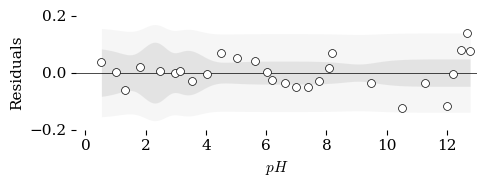

In [139]:
###############################################################################
# Generate smooth curve
###############################################################################

pH_fit = np.linspace(
    np.min(x),
    np.max(x),
    500
)

# Best-fit curve
y_fit = result.eval(pH=pH_fit)

derr_upper = ci_upper - y_fit
derr_lower = y_fit - ci_lower

prediction_upper = pi_upper - y_fit
prediction_lower = y_fit - pi_lower

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,2))  

################################################################################
### Plot the data and the line fit.   
################################################################################

ax.axhline(0, linewidth = 0.5)

ax.scatter(x, y - result.eval(pH=x), 
           marker = "o", s=32, 
           color="white", edgecolor = "black",
           linewidth = 0.5, zorder=3)

################################################################################
### Set labels and scale 
################################################################################

ax.set(ylabel=r"Residuals", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-0.2,0.2]
      )

#ax.margins(x=.07, y=.07, tight=True)  # add 7% empty space around outside of plot area   


# upper and lower bounds of uncertain kobs as float values

################################################################################
### Create Confidence band upper and lower bounds
################################################################################

ax.fill_between(pH_fit, -derr_upper, derr_lower, 
                   color="lightgray", alpha=0.5, zorder = 0,
                   linewidth=0, label="confidence interval")

# prediction inteerval bounds
ax.fill_between(pH_fit, -prediction_upper, prediction_lower,
                   color="lightgray", alpha=0.20, zorder = 0,
                   linewidth=0, label="prediction interval")

#############################
### Output the final plot ###
#############################

fig.savefig("plots/06_plot_pH3_LMFit_residuals.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots


## Studentized Bootstrap

In [142]:
import numpy as np
import pandas as pd

def studentized_bootstrap(
    model,
    result,
    x,
    nboot=2000,
    seed=123
):
    """
    Studentized bootstrap for LMFit models.

    Returns:
        parameter table with 95% studentized intervals
    """

    rng = np.random.default_rng(seed)

    residuals = result.data - result.best_fit

    param_names = result.var_names

    original_values = {
        p: result.params[p].value
        for p in param_names
    }

    original_se = {
        p: result.params[p].stderr
        for p in param_names
    }

    t_values = {
        p: []
        for p in param_names
    }

    successful = 0

    for i in range(nboot):

        try:

            resampled_residuals = rng.choice(
                residuals,
                size=len(residuals),
                replace=True
            )

            y_boot = (
                result.best_fit
                + resampled_residuals
            )

            boot = model.fit(
                y_boot,
                result.params.copy(),
                pH=x
            )

            if boot.covar is None:
                continue

            for pname in param_names:

                theta_star = (
                    boot.params[pname].value
                )

                se_star = (
                    boot.params[pname].stderr
                )

                if (
                    se_star is None
                    or se_star <= 0
                ):
                    continue

                t_boot = (
                    theta_star
                    - original_values[pname]
                ) / se_star

                t_values[pname].append(
                    t_boot
                )

            successful += 1

        except Exception:
            continue

    rows = []

    for pname in param_names:

        tdist = np.array(
            t_values[pname]
        )

        t_low = np.percentile(
            tdist,
            2.5
        )

        t_high = np.percentile(
            tdist,
            97.5
        )

        theta_hat = original_values[pname]

        se_hat = original_se[pname]

        ci_lower = (
            theta_hat
            - t_high * se_hat
        )

        ci_upper = (
            theta_hat
            - t_low * se_hat
        )

        rows.append(
            {
                "Parameter": pname,
                "Estimate": theta_hat,
                "StdErr": se_hat,
                "Lower95": ci_lower,
                "Upper95": ci_upper,
            }
        )

    table = pd.DataFrame(rows)

    print(
        f"\nSuccessful bootstrap fits: "
        f"{successful}/{nboot}"
    )

    return table

In [143]:
ci_table = studentized_bootstrap(
    gmodel,
    result,
    x,
    nboot=5000
)

print(ci_table)


Successful bootstrap fits: 5000/5000
  Parameter      Estimate      StdErr       Lower95       Upper95
0        ka      1.749575    0.173942      1.412617      2.132830
1        kb      0.013848    0.004596      0.004125      0.023432
2        kc      0.119872    0.005430      0.109086      0.131497
3        kd  15075.759868  808.222341  13487.382619  16832.828121
4       pKa      3.654090    0.123266      3.409252      3.926424


In [149]:
from scipy.stats import t
import pandas as pd

n = result.ndata
p = result.nvarys
dof = n - p

tval = t.ppf(0.975, dof)

rows = []

for name in result.var_names:

    par = result.params[name]

    rows.append({
        "Parameter": name,
        "Value": par.value,
        "StdErr": par.stderr,
        "Lower95": par.value - tval * par.stderr,
        "Upper95": par.value + tval * par.stderr
    })

ci_table = pd.DataFrame(rows)

print(ci_table)

  Parameter         Value      StdErr       Lower95       Upper95
0        ka      1.749575    0.173942      1.389749      2.109401
1        kb      0.013848    0.004596      0.004340      0.023357
2        kc      0.119872    0.005430      0.108639      0.131105
3        kd  15075.759868  808.222341  13403.824571  16747.695164
4       pKa      3.654090    0.123266      3.399096      3.909085


In [150]:
from scipy.stats import t

def studentized_confidence_band(
    model,
    result,
    x,
    pH_grid,
    nboot=2000,
    seed=123
):

    rng = np.random.default_rng(seed)

    residuals = (
        result.data
        - result.best_fit
    )

    y_hat = result.eval(
        pH=pH_grid
    )

    lower_t = []
    upper_t = []

    # standard errors for original fit
    cov = result.covar

    if cov is None:
        raise ValueError(
            "Original fit lacks covariance matrix."
        )

    param_names = result.var_names

    # compute original SE band
    def compute_se_curve(
        params,
        cov
    ):

        npar = len(param_names)

        jac = np.zeros(
            (len(pH_grid), npar)
        )

        eps = 1e-7

        for j, pname in enumerate(param_names):

            value = params[pname].value

            step = (
                eps
                * max(abs(value), 1)
            )

            plus = params.copy()
            minus = params.copy()

            plus[pname].value += step
            minus[pname].value -= step

            y_plus = model.eval(
                plus,
                pH=pH_grid
            )

            y_minus = model.eval(
                minus,
                pH=pH_grid
            )

            jac[:, j] = (
                y_plus - y_minus
            ) / (2 * step)

        se_curve = np.zeros(
            len(pH_grid)
        )

        for i in range(len(pH_grid)):

            J = jac[i]

            se_curve[i] = np.sqrt(
                J @ cov @ J.T
            )

        return se_curve

    se_original = compute_se_curve(
        result.params,
        result.covar
    )

    t_samples = []

    for _ in range(nboot):

        try:

            resampled = rng.choice(
                residuals,
                len(residuals),
                replace=True
            )

            y_boot = (
                result.best_fit
                + resampled
            )

            boot = model.fit(
                y_boot,
                result.params.copy(),
                pH=x
            )

            if boot.covar is None:
                continue

            y_boot_curve = boot.eval(
                pH=pH_grid
            )

            se_boot = compute_se_curve(
                boot.params,
                boot.covar
            )

            t_curve = (
                y_boot_curve
                - y_hat
            ) / se_boot

            t_samples.append(
                t_curve
            )

        except Exception:
            pass

    t_samples = np.array(
        t_samples
    )

    t_low = np.percentile(
        t_samples,
        2.5,
        axis=0
    )

    t_high = np.percentile(
        t_samples,
        97.5,
        axis=0
    )

    ci_lower = (
        y_hat
        - t_high * se_original
    )

    ci_upper = (
        y_hat
        - t_low * se_original
    )

    return (
        y_hat,
        ci_lower,
        ci_upper
    )

In [162]:
se_boot

NameError: name 'se_boot' is not defined

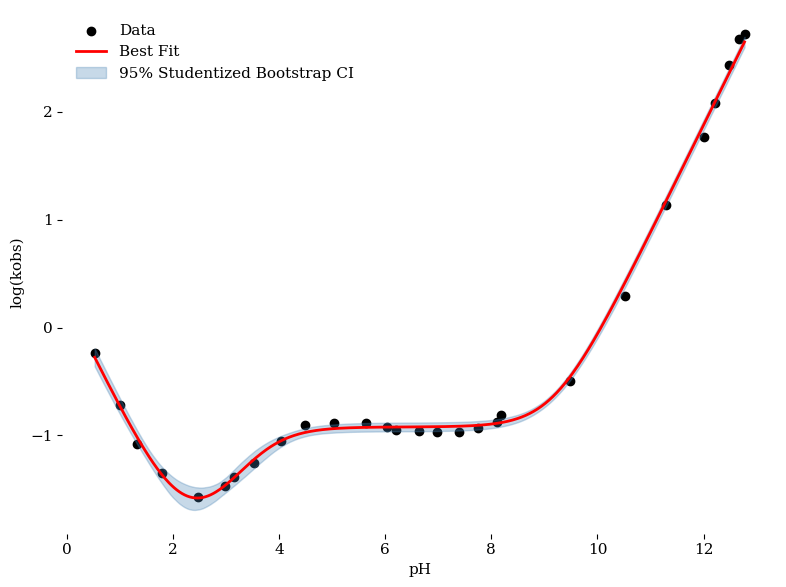

In [151]:
pH_grid = np.linspace(
    np.min(x),
    np.max(x),
    500
)

y_fit, ci_low, ci_high = (
    studentized_confidence_band(
        gmodel,
        result,
        x,
        pH_grid,
        nboot=5000
    )
)

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    color="black",
    label="Data"
)

plt.plot(
    pH_grid,
    y_fit,
    color="red",
    lw=2,
    label="Best Fit"
)

plt.fill_between(
    pH_grid,
    ci_low,
    ci_high,
    color="steelblue",
    alpha=0.3,
    label="95% Studentized Bootstrap CI"
)

plt.xlabel("pH")
plt.ylabel("log(kobs)")
plt.legend()
plt.tight_layout()
plt.show()

## Bca Bootstrap

In [158]:
import numpy as np
import pandas as pd

from scipy.stats import fit, norm

def bca_bootstrap_parameters(
    model,
    result,
    x,
    nboot=5000,
    alpha=0.05,
    seed=123,
):
    """
    BCa bootstrap confidence intervals
    for LMFit parameters.

    Parameters
    ----------
    model : lmfit.Model

    result : lmfit.ModelResult

    x : ndarray
        Original x values (pH)

    nboot : int

    alpha : float
        0.05 -> 95% CI

    Returns
    -------
    DataFrame
    """

    rng = np.random.default_rng(seed)

    residuals = (
        result.data
        - result.best_fit
    )

    param_names = result.var_names

    theta_hat = {
        p: result.params[p].value
        for p in param_names
    }
    curve_samples = []
    # ----------------------------------------------------------
    # Bootstrap
    # ----------------------------------------------------------

    boot = {
        p: []
        for p in param_names
    }

    successes = 0

    for i in range(nboot):

        try:

            resampled = rng.choice(
                residuals,
                size=len(residuals),
                replace=True,
            )

            y_boot = (
                result.best_fit
                + resampled
            )

            fit = model.fit(
                y_boot,
                result.params.copy(),
                pH=x,
            )

            for p in param_names:

                boot[p].append(
                    fit.params[p].value
                )

            curve = fit.eval(pH=pH_grid)
            curve_samples.append(curve)

            successes += 1

        except Exception:
            pass

    print(
        f"Successful fits: "
        f"{successes}/{nboot}"
    )

    # ----------------------------------------------------------
    # Jackknife for acceleration
    # ----------------------------------------------------------

    jackknife = {}

    for pname in param_names:

        jackknife[pname] = []

    n = len(x)

    for i in range(n):

        try:

            x_jack = np.delete(x, i)
            y_jack = np.delete(
                result.data,
                i
            )

            fit_jack = model.fit(
                y_jack,
                result.params.copy(),
                pH=x_jack,
            )

            for pname in param_names:

                jackknife[pname].append(
                    fit_jack.params[pname].value
                )

        except Exception:
            pass

    # ----------------------------------------------------------
    # BCa interval calculation
    # ----------------------------------------------------------

    rows = []

    z_alpha_low = norm.ppf(alpha / 2)
    z_alpha_high = norm.ppf(1 - alpha / 2)

    for pname in param_names:

        bootvals = np.asarray(
            boot[pname]
        )

        theta0 = theta_hat[pname]

        # ---------------------------------
        # Bias correction z0
        # ---------------------------------

        prop_less = np.mean(
            bootvals < theta0
        )

        prop_less = np.clip(
            prop_less,
            1e-6,
            1 - 1e-6
        )

        z0 = norm.ppf(prop_less)

        # ---------------------------------
        # Acceleration from jackknife
        # ---------------------------------

        jack = np.asarray(
            jackknife[pname]
        )

        jack_mean = np.mean(jack)

        num = np.sum(
            (jack_mean - jack) ** 3
        )

        den = (
            6.0
            * np.sum(
                (jack_mean - jack) ** 2
            ) ** 1.5
        )

        if den == 0:
            accel = 0.0
        else:
            accel = num / den

        # ---------------------------------
        # BCa-adjusted probabilities
        # ---------------------------------

        adj_low = norm.cdf(
            z0
            + (
                z0 + z_alpha_low
            )
            /
            (
                1
                - accel
                * (
                    z0 + z_alpha_low
                )
            )
        )

        adj_high = norm.cdf(
            z0
            + (
                z0 + z_alpha_high
            )
            /
            (
                1
                - accel
                * (
                    z0 + z_alpha_high
                )
            )
        )

        lower = np.quantile(
            bootvals,
            adj_low
        )

        upper = np.quantile(
            bootvals,
            adj_high
        )
        curve_samples = np.asarray(curve_samples)
        rows.append(
            {
                "Parameter": pname,
                "Estimate": theta0,
                "Lower95": lower,
                "Upper95": upper,
                "BiasCorr_z0": z0,
                "Acceleration": accel,
            }
        )

    return pd.DataFrame(rows), curve_samples

In [159]:
bca_table, curve_samples = bca_bootstrap_parameters(
    gmodel,
    result,
    x,
    nboot=5000,
)

print(bca_table)

Successful fits: 5000/5000
  Parameter      Estimate       Lower95       Upper95  BiasCorr_z0  \
0        ka      1.749575      1.469708      2.100978    -0.001504   
1        kb      0.013848      0.005451      0.021822     0.013536   
2        kc      0.119872      0.110834      0.130169     0.012533   
3        kd  15075.759868  13755.654481  16648.758257     0.027075   
4       pKa      3.654090      3.445852      3.897419    -0.029081   

   Acceleration  
0      0.019900  
1     -0.011784  
2      0.008865  
3      0.000757  
4      0.039054  


In [160]:
ci_low = np.zeros(len(pH_grid))
ci_high = np.zeros(len(pH_grid))

for j in range(len(pH_grid)):

    values = curve_samples[:, j]

    ci_low[j] = np.quantile(
        values,
        0.025
    )

    ci_high[j] = np.quantile(
        values,
        0.975
    )

In [ ]:
plt.fill_between(
    pH_grid,
    ci_low,
    ci_high,
    alpha=0.3,
    color="steelblue",
    label="95% BCa CI"
)

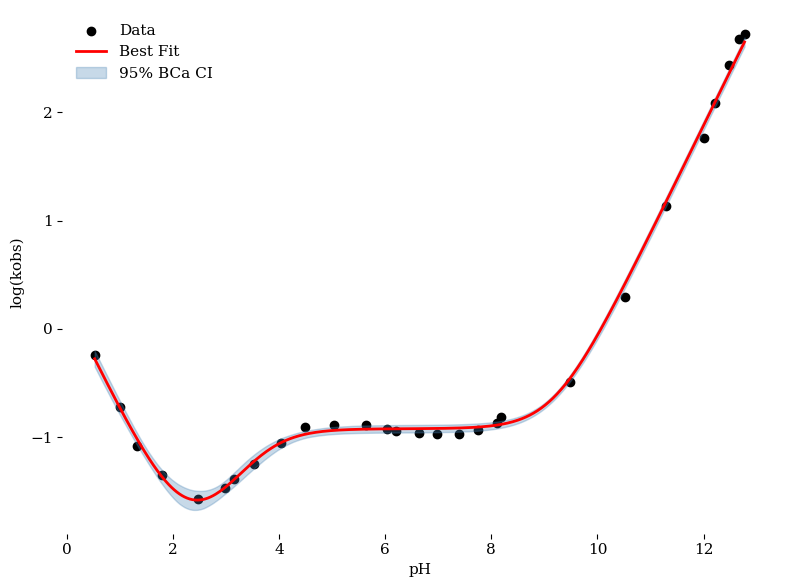

In [161]:

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    color="black",
    label="Data"
)

plt.plot(
    pH_grid,
    y_fit,
    color="red",
    lw=2,
    label="Best Fit"
)

plt.fill_between(
    pH_grid,
    ci_low,
    ci_high,
    alpha=0.3,
    color="steelblue",
    label="95% BCa CI"
)

plt.xlabel("pH")
plt.ylabel("log(kobs)")
plt.legend()
plt.tight_layout()
plt.show()

### Prediction Interval

Successful fits: 5000/5000
Residual SD = 0.0629


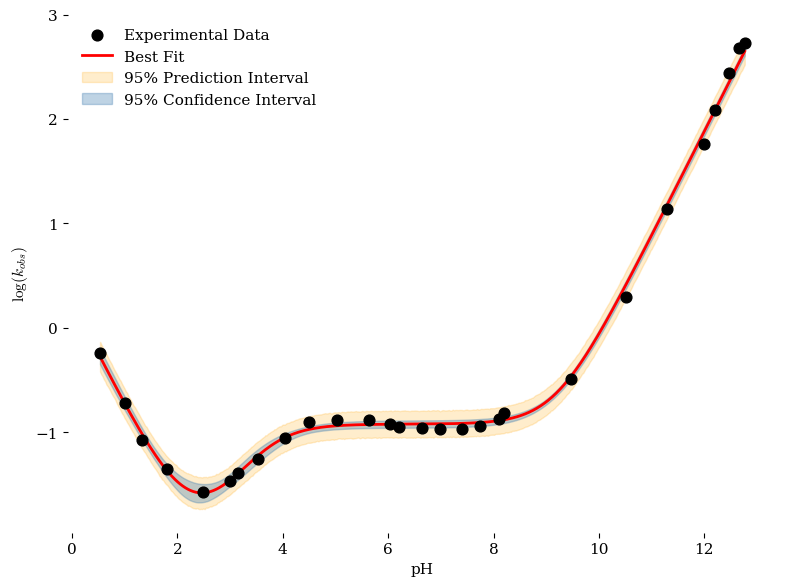

In [163]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# Bootstrap confidence and prediction bands
###############################################################################

nboot = 5000
seed = 123

rng = np.random.default_rng(seed)

###############################################################################
# Smooth pH grid
###############################################################################

pH_grid = np.linspace(
    np.min(x),
    np.max(x),
    500
)

###############################################################################
# Original fitted curve
###############################################################################

y_fit = result.eval(
    pH=pH_grid
)

###############################################################################
# Residuals from original fit
###############################################################################

residuals = (
    result.data
    - result.best_fit
)

###############################################################################
# Storage
###############################################################################

curve_samples = []

successful = 0

###############################################################################
# Residual bootstrap
###############################################################################

for i in range(nboot):

    try:

        resampled_residuals = rng.choice(
            residuals,
            size=len(residuals),
            replace=True
        )

        y_boot = (
            result.best_fit
            + resampled_residuals
        )

        boot = gmodel.fit(
            y_boot,
            result.params.copy(),
            pH=x
        )

        curve = boot.eval(
            pH=pH_grid
        )

        curve_samples.append(curve)

        successful += 1

    except Exception:
        pass

curve_samples = np.asarray(
    curve_samples
)

print(
    f"Successful fits: "
    f"{successful}/{nboot}"
)

###############################################################################
# 95% bootstrap confidence band
###############################################################################

ci_lower = np.percentile(
    curve_samples,
    2.5,
    axis=0
)

ci_upper = np.percentile(
    curve_samples,
    97.5,
    axis=0
)

###############################################################################
# Estimate residual distribution
###############################################################################

sigma_resid = np.std(
    residuals,
    ddof=result.nvarys
)

print(
    f"Residual SD = "
    f"{sigma_resid:.4f}"
)

###############################################################################
# Create prediction samples
###############################################################################

prediction_samples = (
    curve_samples
    + rng.normal(
        0,
        sigma_resid,
        curve_samples.shape
    )
)

###############################################################################
# 95% prediction band
###############################################################################

pi_lower = np.percentile(
    prediction_samples,
    2.5,
    axis=0
)

pi_upper = np.percentile(
    prediction_samples,
    97.5,
    axis=0
)

###############################################################################
# Plot
###############################################################################

plt.figure(figsize=(8, 6))

# Experimental data

plt.scatter(
    x,
    y,
    color="black",
    s=60,
    zorder=10,
    label="Experimental Data"
)

# Best-fit curve

plt.plot(
    pH_grid,
    y_fit,
    color="red",
    lw=2,
    label="Best Fit"
)

# Prediction interval (plot first)

plt.fill_between(
    pH_grid,
    pi_lower,
    pi_upper,
    color="orange",
    alpha=0.20,
    label="95% Prediction Interval"
)

# Confidence interval

plt.fill_between(
    pH_grid,
    ci_lower,
    ci_upper,
    color="steelblue",
    alpha=0.35,
    label="95% Confidence Interval"
)

plt.xlabel("pH")
plt.ylabel(r"$\log(k_{obs})$")

plt.legend()

plt.tight_layout()

plt.show()

[[Model]]
    Model(michaelis_menten)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 10
    # variables        = 2
    chi-square         = 2.69884131
    reduced chi-square = 0.33735516
    Akaike info crit   = -9.09762558
    Bayesian info crit = -8.49245539
    R-squared          = 0.99865205
[[Variables]]
    vmax:  52.6728511 +/- 0.67963689 (1.29%) (init = 50)
    km:    6.81699667 +/- 0.26055286 (3.82%) (init = 5)
[[Correlations]] (unreported correlations are < 0.100)
    C(vmax, km) = +0.8695


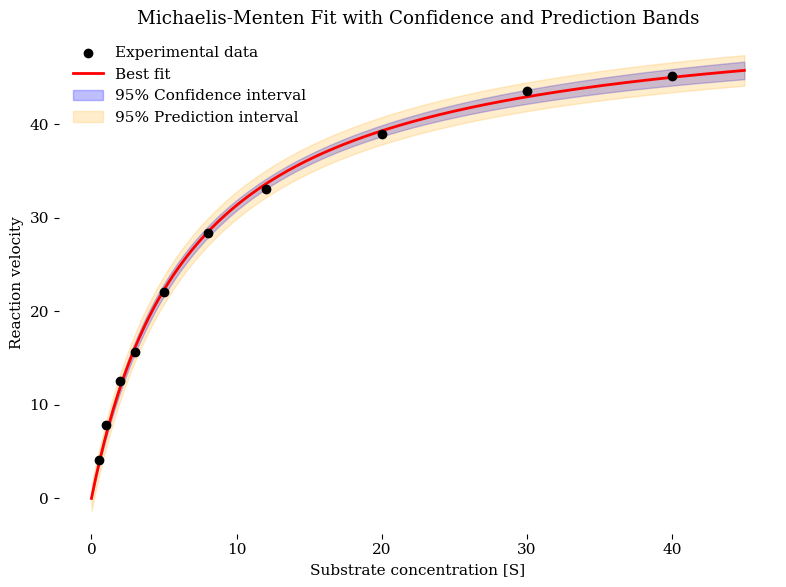

In [98]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# -----------------------------------------------------------------------------
# Example Michaelis-Menten data
# -----------------------------------------------------------------------------

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

n = len(S)

# -----------------------------------------------------------------------------
# Michaelis-Menten model
# -----------------------------------------------------------------------------

def michaelis_menten(S, vmax, km):
    return vmax * S / (km + S)

model = Model(michaelis_menten)

params = model.make_params(
    vmax=50,
    km=5
)

result = model.fit(v, params, S=S)

print(result.fit_report())

# -----------------------------------------------------------------------------
# Smooth curve for plotting
# -----------------------------------------------------------------------------

xfit = np.linspace(0, 45, 300)

yfit = result.eval(S=xfit)

# -----------------------------------------------------------------------------
# Confidence interval from covariance matrix
# -----------------------------------------------------------------------------

cov = result.covar

# fitted parameters
vmax_hat = result.params['vmax'].value
km_hat = result.params['km'].value

# Jacobian-based confidence bands
var_mean = np.zeros_like(xfit)

for i, x in enumerate(xfit):

    # Partial derivatives
    d_vmax = x / (km_hat + x)

    d_km = -vmax_hat * x / (km_hat + x)**2

    J = np.array([d_vmax, d_km])

    var_mean[i] = J @ cov @ J.T

se_mean = np.sqrt(var_mean)

# -----------------------------------------------------------------------------
# Residual variance
# -----------------------------------------------------------------------------

rss = np.sum(result.residual**2)
p = len(result.var_names)
dof = n - p

mse = rss / dof

# -----------------------------------------------------------------------------
# 95% confidence interval
# -----------------------------------------------------------------------------

alpha = 0.05
tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# -----------------------------------------------------------------------------
# 95% prediction interval
# -----------------------------------------------------------------------------

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    S, v,
    color='black',
    zorder=3,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    linewidth=2,
    label='Best fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.25,
    label='95% Confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% Prediction interval'
)

plt.xlabel("Substrate concentration [S]")
plt.ylabel("Reaction velocity")
plt.title("Michaelis-Menten Fit with Confidence and Prediction Bands")

plt.legend()
plt.tight_layout()
plt.show()



[[Model]]
    Model(line)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 10
    # variables        = 2
    chi-square         = 7.2824e-05
    reduced chi-square = 9.1030e-06
    Akaike info crit   = -114.300456
    Bayesian info crit = -113.695286
    R-squared          = 0.99833085
[[Variables]]
    slope:      0.11099207 +/- 0.00160457 (1.45%) (init = 0.5)
    intercept:  0.02149346 +/- 0.00118215 (5.50%) (init = 0.02)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.5904

Vmax = 46.526
Km   = 5.164


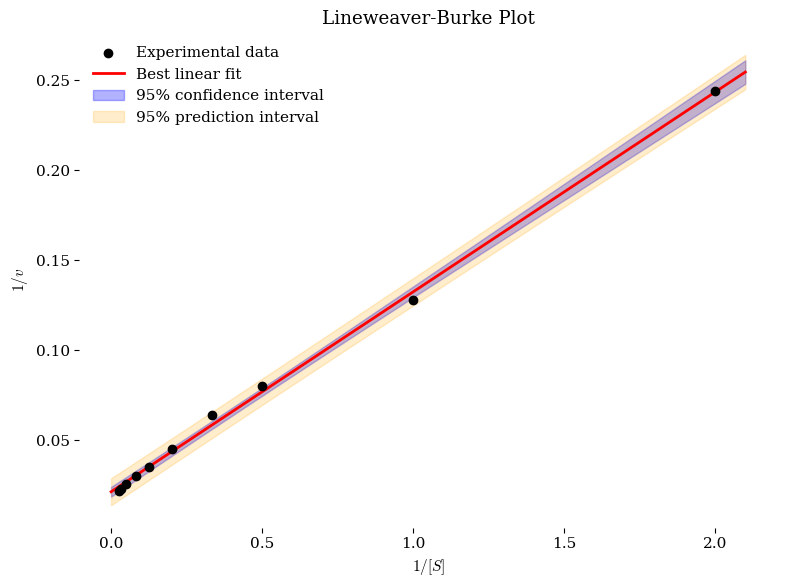

In [99]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# =============================================================================
# Example Michaelis-Menten data
# =============================================================================

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

# =============================================================================
# Transform to Lineweaver-Burke coordinates
# =============================================================================

x = 1 / S
y = 1 / v

n = len(x)

# =============================================================================
# Linear model
# =============================================================================

def line(x, slope, intercept):
    return slope*x + intercept

model = Model(line)

params = model.make_params(
    slope=0.5,
    intercept=0.02
)

result = model.fit(y, params, x=x)

print(result.fit_report())

# =============================================================================
# Extract fit parameters
# =============================================================================

m = result.params["slope"].value
b = result.params["intercept"].value

# Derived kinetic parameters

Vmax = 1/b
Km = m/b

print(f"\nVmax = {Vmax:.3f}")
print(f"Km   = {Km:.3f}")

# =============================================================================
# Generate smooth line
# =============================================================================

xfit = np.linspace(0, x.max()*1.05, 300)

yfit = result.eval(x=xfit)

# =============================================================================
# Confidence interval calculations
# =============================================================================

cov = result.covar

var_mean = np.zeros_like(xfit)

for i, xx in enumerate(xfit):

    jacobian = np.array([xx, 1.0])

    var_mean[i] = jacobian @ cov @ jacobian.T

se_mean = np.sqrt(var_mean)

# =============================================================================
# Residual variance
# =============================================================================

rss = np.sum(result.residual**2)

p = len(result.var_names)

dof = n - p

mse = rss / dof

# =============================================================================
# 95% confidence interval
# =============================================================================

alpha = 0.05

tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# =============================================================================
# 95% prediction interval
# =============================================================================

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# =============================================================================
# Plot
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    color='black',
    zorder=10,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    lw=2,
    label='Best linear fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.30,
    label='95% confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% prediction interval'
)

plt.xlabel(r'$1/[S]$')
plt.ylabel(r'$1/v$')

plt.title('Lineweaver-Burke Plot')

plt.legend()

plt.tight_layout()

plt.show()

## MM Confidence Interval

[[Model]]
    Model(michaelis_menten)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 16
    # data points      = 10
    # variables        = 2
    chi-square         = 2.69884131
    reduced chi-square = 0.33735516
    Akaike info crit   = -9.09762558
    Bayesian info crit = -8.49245539
    R-squared          = 0.99865205
[[Variables]]
    vmax:  52.6728511 +/- 0.67963689 (1.29%) (init = 50)
    km:    6.81699667 +/- 0.26055286 (3.82%) (init = 5)
[[Correlations]] (unreported correlations are < 0.100)
    C(vmax, km) = +0.8695


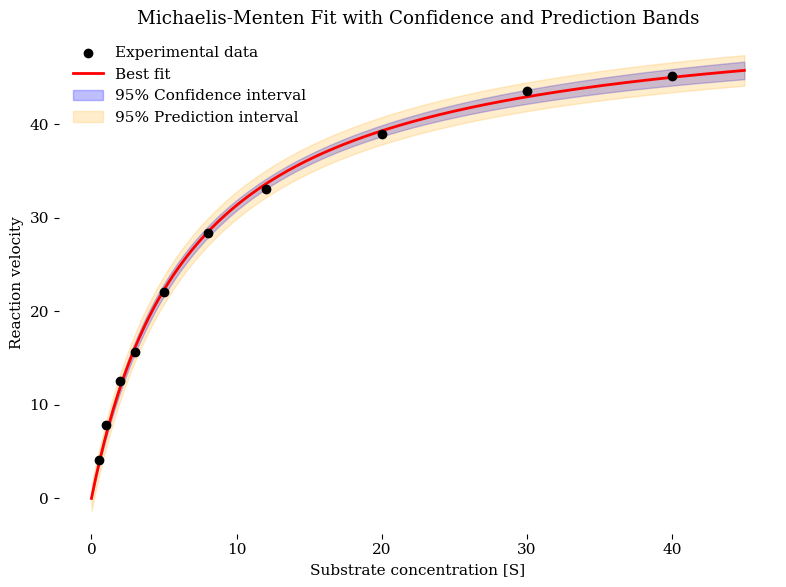

In [100]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# -----------------------------------------------------------------------------
# Example Michaelis-Menten data
# -----------------------------------------------------------------------------

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

n = len(S)

# -----------------------------------------------------------------------------
# Michaelis-Menten model
# -----------------------------------------------------------------------------

def michaelis_menten(S, vmax, km):
    return vmax * S / (km + S)

model = Model(michaelis_menten)

params = model.make_params(
    vmax=50,
    km=5
)

result = model.fit(v, params, S=S)

print(result.fit_report())

# -----------------------------------------------------------------------------
# Smooth curve for plotting
# -----------------------------------------------------------------------------

xfit = np.linspace(0, 45, 300) # Array of x-values for smooth curve
yfit = result.eval(S=xfit)     # Evaluate the fitted model at each x-value

# -----------------------------------------------------------------------------
# Confidence interval from covariance matrix
# -----------------------------------------------------------------------------

cov = result.covar # covariance matrix of the fitted parameters

# fitted parameters
vmax_hat = result.params['vmax'].value      # Fitted value of Vmax
km_hat = result.params['km'].value          # Fitted value of Km

# Jacobian-based confidence bands
var_mean = np.zeros_like(xfit)
for i, x in enumerate(xfit): 
    # Partial derivatives
    d_vmax = x / (km_hat + x)               # Partial derivative with respect to Vmax
    d_km = -vmax_hat * x / (km_hat + x)**2  # Partial derivative with respect to Km
    J = np.array([d_vmax, d_km])            # Jacobian for Michaelis-Menten model
    var_mean[i] = J @ cov @ J.T             # Jacobian-based confidence bands
se_mean = np.sqrt(var_mean)           # The standard error of the predicted mean response at each value of xfit

# -----------------------------------------------------------------------------
# Residual variance
# -----------------------------------------------------------------------------

rss = np.sum(result.residual**2)
p = len(result.var_names)
dof = n - p

mse = rss / dof

# -----------------------------------------------------------------------------
# 95% confidence interval
# -----------------------------------------------------------------------------

alpha = 0.05
tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# -----------------------------------------------------------------------------
# 95% prediction interval
# -----------------------------------------------------------------------------

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# -----------------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    S, v,
    color='black',
    zorder=3,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    linewidth=2,
    label='Best fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.25,
    label='95% Confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% Prediction interval'
)

plt.xlabel("Substrate concentration [S]")
plt.ylabel("Reaction velocity")
plt.title("Michaelis-Menten Fit with Confidence and Prediction Bands")

plt.legend()
plt.tight_layout()
plt.show()

## LB Confidence Interval

[[Model]]
    Model(line)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 10
    # variables        = 2
    chi-square         = 7.2824e-05
    reduced chi-square = 9.1030e-06
    Akaike info crit   = -114.300456
    Bayesian info crit = -113.695286
    R-squared          = 0.99833085
[[Variables]]
    slope:      0.11099207 +/- 0.00160457 (1.45%) (init = 0.5)
    intercept:  0.02149346 +/- 0.00118215 (5.50%) (init = 0.02)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.5904

Vmax = 46.526
Km   = 5.164


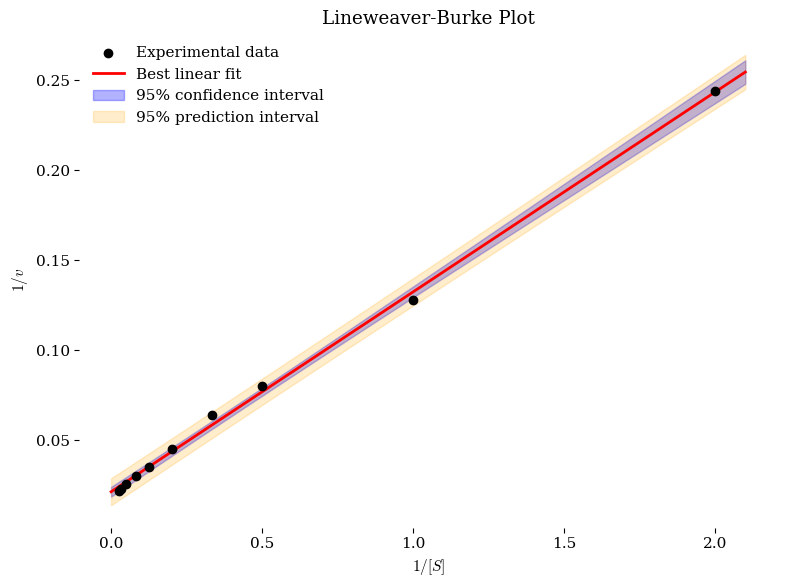

In [101]:
import numpy as np
import matplotlib.pyplot as plt

from lmfit import Model
from scipy.stats import t

# =============================================================================
# Example Michaelis-Menten data
# =============================================================================

S = np.array([0.5, 1, 2, 3, 5, 8, 12, 20, 30, 40])
v = np.array([4.1, 7.8, 12.5, 15.6, 22.1,
              28.4, 33.1, 38.9, 43.5, 45.1])

# =============================================================================
# Transform to Lineweaver-Burke coordinates
# =============================================================================

x = 1 / S
y = 1 / v

n = len(x)

# =============================================================================
# Linear model
# =============================================================================

def line(x, slope, intercept):
    return slope*x + intercept

model = Model(line)

params = model.make_params(
    slope=0.5,
    intercept=0.02
)

result = model.fit(y, params, x=x)

print(result.fit_report())

# =============================================================================
# Extract fit parameters
# =============================================================================

m = result.params["slope"].value
b = result.params["intercept"].value

# Derived kinetic parameters

Vmax = 1/b
Km = m/b

print(f"\nVmax = {Vmax:.3f}")
print(f"Km   = {Km:.3f}")

# =============================================================================
# Generate smooth line
# =============================================================================

xfit = np.linspace(0, x.max()*1.05, 300)

yfit = result.eval(x=xfit)

# =============================================================================
# Confidence interval calculations
# =============================================================================

cov = result.covar

var_mean = np.zeros_like(xfit)

for i, xx in enumerate(xfit):

    jacobian = np.array([xx, 1.0]) # Jacobian for linear model

    var_mean[i] = jacobian @ cov @ jacobian.T # Jacobian-based confidence bands

se_mean = np.sqrt(var_mean)

# =============================================================================
# Residual variance
# =============================================================================

rss = np.sum(result.residual**2)

p = len(result.var_names)

dof = n - p

mse = rss / dof

# =============================================================================
# 95% confidence interval
# =============================================================================

alpha = 0.05

tval = t.ppf(1 - alpha/2, dof)

ci_upper = yfit + tval * se_mean
ci_lower = yfit - tval * se_mean

# =============================================================================
# 95% prediction interval
# =============================================================================

se_pred = np.sqrt(se_mean**2 + mse)

pi_upper = yfit + tval * se_pred
pi_lower = yfit - tval * se_pred

# =============================================================================
# Plot
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    color='black',
    zorder=10,
    label='Experimental data'
)

plt.plot(
    xfit,
    yfit,
    color='red',
    lw=2,
    label='Best linear fit'
)

plt.fill_between(
    xfit,
    ci_lower,
    ci_upper,
    color='blue',
    alpha=0.30,
    label='95% confidence interval'
)

plt.fill_between(
    xfit,
    pi_lower,
    pi_upper,
    color='orange',
    alpha=0.20,
    label='95% prediction interval'
)

plt.xlabel(r'$1/[S]$')
plt.ylabel(r'$1/v$')

plt.title('Lineweaver-Burke Plot')

plt.legend()

plt.tight_layout()

plt.show()